In [41]:
import sys

In [42]:
sys.dont_write_bytecode = True

In [43]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from GaussianMixtureModel import GaussianMixtureModel

In [44]:
np.random.seed(0)

In [45]:
olivetti_faces = fetch_olivetti_faces()

X = olivetti_faces.data

Y = olivetti_faces.target

In [46]:
PERSONS = np.unique(Y)

In [47]:
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(

    X, Y, stratify = Y,

    test_size = 0.1

)

In [48]:
N_TRAIN = Y_TRAIN.shape[0]

N_TEST = Y_TEST.shape[0]

In [49]:
PRE_PROCESSING = Pipeline(

    steps = [

        ('StandardScaler', StandardScaler()),
        
        ('PCA', PCA())

    ]

)

PRE_PROCESSING.fit(X_TRAIN);

In [50]:
PCA_GRID = pd.DataFrame(

    data = {

        'Número de Componentes' : np.arange(PRE_PROCESSING.named_steps['PCA'].components_.shape[0]) + 1,

        'Variância Explicada' : np.cumsum(PRE_PROCESSING.named_steps['PCA'].explained_variance_ratio_)

    }

)

PCA_GRID.head()

,Número de Componentes,Variância Explicada
0,1,0.266724
1,2,0.390072
2,3,0.468075
3,4,0.516056
4,5,0.548774


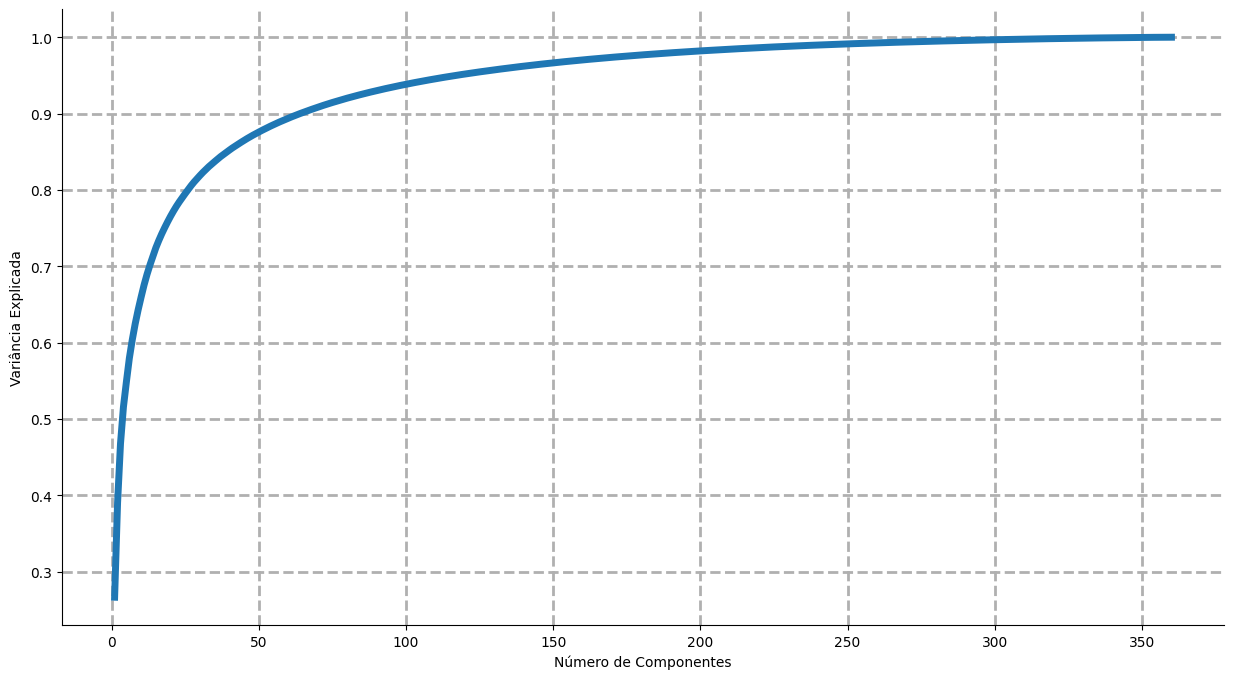

In [51]:
plt.figure(figsize = (15, 8))

GRAPH = sns.lineplot(

    data = PCA_GRID, 
    
    x = 'Número de Componentes', 
    
    y = 'Variância Explicada',

    linewidth = 5

)

GRAPH.spines['top'].set_visible(False)

GRAPH.spines['right'].set_visible(False)

plt.grid(linestyle = '--', linewidth = 2)

plt.show()

In [52]:
PRE_PROCESSING.set_params(PCA__n_components = 0.8);

X_TRAIN_PCA = PRE_PROCESSING.fit_transform(X_TRAIN)

X_TEST_PCA = PRE_PROCESSING.transform(X_TEST)

In [53]:
GMM, M = {}, 4

for PERSON in PERSONS:

    X_PERSON = X_TRAIN_PCA[np.where(Y_TRAIN == PERSON)]

    GMM[f'{PERSON}'] = GaussianMixtureModel(X_PERSON, M)

    GMM[f'{PERSON}'].update_model()

In [54]:
PROB = []

for PERSON in PERSONS:

    PROB.append(GMM[f'{PERSON}'].posterior_predictive(X_TEST_PCA))

PROB = np.array(PROB).T

Y_PRED = PROB.argmax(axis = 1)

print(np.sum(Y_TEST == Y_PRED)/N_TEST)

0.925


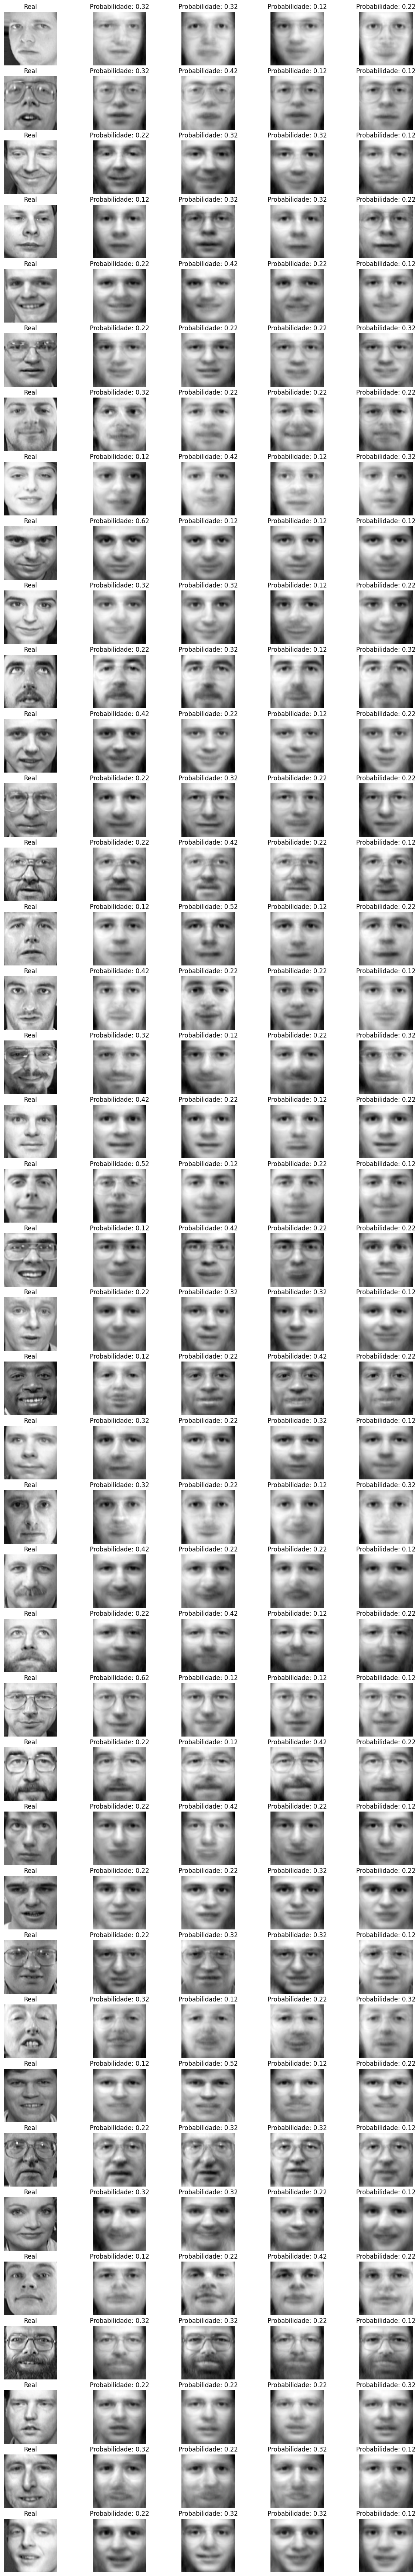

In [ ]:
fig, ax = plt.subplots(len(PERSONS), M + 1, figsize = (15, 90))

for PERSON in PERSONS:

    ax[PERSON, 0].imshow(X_TEST[np.where(Y_TEST == PERSON)].reshape((64, 64)), cmap = 'gray')

    ax[PERSON, 0].set_title(f'Imagem Real')

    ax[PERSON, 0].axis('off')

    PERSON_MU = PRE_PROCESSING.inverse_transform(GMM[f'{PERSON}'].mu)

    for m in range(M):

        ax[PERSON, m + 1].imshow(PERSON_MU[m].reshape((64, 64)), cmap = 'gray')

        ax[PERSON, m + 1].set_title(f'Probabilidade: {np.round(GMM[f'{PERSON}'].pi[m], 2)}')

        ax[PERSON, m + 1].axis('off')

plt.show()